In [1]:
import torch
import torchvision
import torchvision.datasets as datasets

In [2]:
mnist_datasets = datasets.MNIST(root='./data/', train=True, download=True, transform=None)

In [3]:
mnist_testset = datasets.MNIST(root='./data/', train=False, download=True, transform=None)

In [4]:
len(mnist_datasets)

60000

In [5]:
len(mnist_testset)

10000

In [6]:
import matplotlib.pyplot as plt

In [7]:
image, label = mnist_datasets[7]

<function matplotlib.pyplot.show(close=None, block=None)>

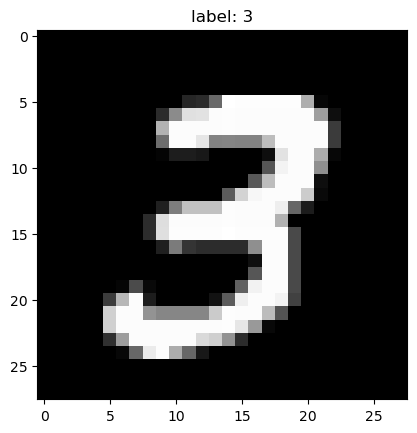

In [8]:
plt.imshow(image, cmap='gray')
plt.title(f'label: {label}')
plt.show

In [9]:
train_image_zero, train_target_zero = mnist_datasets[5]

In [10]:
train_image_zero.show()

In [11]:
print(train_target_zero)

2


## Building a Simple MNIST Classifier using pytorch

In [12]:
import torch
import torchvision
import torchvision.datasets as torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torch import nn, optim

In [13]:
# prepare the data
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.MNIST(root='./', train=True, transform=transform, download=True)
testset = torchvision.MNIST(root='./', train=False, transform=transform, download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

In [14]:
x, y = trainset[1]

In [15]:
#plt.imshow(x, cmap='gray')
#plt.title(f'label: {y}')
#plt.show

In [16]:
print(y)

0


In [17]:
#Build the neural network for forward feed
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(28 * 28, 512) # Hidden layer
        self.output = nn.Linear(512, 10)      # output layer
        self.sigmoid = nn.Sigmoid()           # Activation function
        self.softmax = nn.LogSoftmax(dim=1)   # Output

    def forward(self, x):
        x = self.hidden(x)
        x = self.sigmoid(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

model = Net()

In [18]:
# forward pass and initial loss calculation
criterion = nn.NLLLoss() # define the loss function
images, labels = next(iter(trainloader))
images = images.view(images.shape[0], -1) # flatten the image
prediction = model(images) #forward pass
loss = criterion(prediction, labels)
print(loss)

tensor(2.3963, grad_fn=<NllLossBackward0>)


In [19]:
import torch.nn.functional as F  # Needed for F.softmax

def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):
    # Move the model to the target device (CPU or GPU)
    model = model.to(device)
    
    for epoch in range(1, epochs + 1):
        training_loss = 0.0
        valid_loss = 0.0
        
        # --- 1. TRAINING PHASE ---
        model.train()  # Put model in training mode
        for batch in train_loader:
            optimizer.zero_grad()            # Clear old gradients
            inputs, target = batch
            
            # Flatten images to match linear layer input (28*28 = 784)
            inputs = inputs.view(inputs.shape[0], -1)
            
            inputs = inputs.to(device)
            target = target.to(device)
            
            output = model(inputs)           # Forward pass
            loss = loss_fn(output, target)   # Calculate loss
            loss.backward()                  # Backward pass (gradients)
            optimizer.step()                 # Update weights
            
            training_loss += loss.data.item()
            
        # Average loss for the training epoch
        training_loss /= len(train_loader)
        
        # --- 2. VALIDATION PHASE ---
        model.eval()  # Put model in evaluation mode
        num_correct = 0
        num_examples = 0
        
        # Turn off gradient calculations for faster validation
        with torch.no_grad():
            for batch in val_loader:
                inputs, targets = batch
                inputs = inputs.view(inputs.shape[0], -1) # Flatten images
                inputs = inputs.to(device)
                targets = targets.to(device)
                
                output = model(inputs)
                loss = loss_fn(output, targets)
                valid_loss += loss.data.item()
                
                # Calculate accuracy
                correct = torch.eq(torch.max(F.softmax(output, dim=1), dim=1)[1], targets).view(-1)
                num_correct += torch.sum(correct).item()
                num_examples += correct.shape[0]
                
        valid_loss /= len(val_loader)
        
        # Print progress
        print('Epoch: {}, Training Loss: {:.2f}, Validation Loss: {:.2f}, Accuracy: {:.2f}'.format(
            epoch, training_loss, valid_loss, num_correct / num_examples
        ))

In [20]:
valloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [21]:
# 1. Define the optimizer (e.g., Stochastic Gradient Descent with learning rate 0.01)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 2. Set your loss function
loss_fn = nn.NLLLoss()

# 3. Choose device ("cpu" or "cuda" if GPU is available)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 4. Run the training!
train(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=trainloader,
    val_loader=valloader,
    epochs=10,
    device=device
)

Epoch: 1, Training Loss: 2.09, Validation Loss: 1.80, Accuracy: 0.64
Epoch: 2, Training Loss: 1.46, Validation Loss: 1.13, Accuracy: 0.80
Epoch: 3, Training Loss: 0.96, Validation Loss: 0.80, Accuracy: 0.83
Epoch: 4, Training Loss: 0.72, Validation Loss: 0.63, Accuracy: 0.85
Epoch: 5, Training Loss: 0.60, Validation Loss: 0.54, Accuracy: 0.87
Epoch: 6, Training Loss: 0.53, Validation Loss: 0.49, Accuracy: 0.88
Epoch: 7, Training Loss: 0.49, Validation Loss: 0.45, Accuracy: 0.88
Epoch: 8, Training Loss: 0.46, Validation Loss: 0.42, Accuracy: 0.89
Epoch: 9, Training Loss: 0.43, Validation Loss: 0.40, Accuracy: 0.89
Epoch: 10, Training Loss: 0.41, Validation Loss: 0.39, Accuracy: 0.89


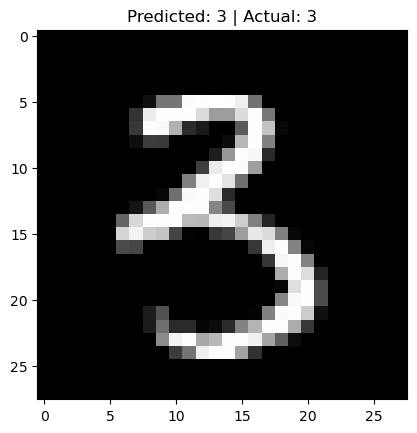

In [23]:
# Grab one image and its true label from the test set
image, label = testset[5000]

# Flatten the image to match model input shape (784)
input_image = image.view(1, 784).to(device)

# Turn off gradient calculation for inference
model.eval()
with torch.no_grad():
    output = model(input_image)

# Get the predicted class (index with highest probability)
predicted_class = torch.argmax(output, dim=1).item()

# Display the image and prediction
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Predicted: {predicted_class} | Actual: {label}')
plt.show()